In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# 0. Check the availability of Cross-species-to-MorphDiff files
# ============================================================

paths = {

    "cross_species_pred_npz": Path(
        "/root/autodl-tmp/scERso/crossspic/"
        "preds_cross_species_residual_v2_atac_boot128_learnedalpha/"
        "mouse_cross_species_preds.npz"
    ),

 
    "mouse_h5ad": Path(
        "/root/autodl-fs/k_spices/processed/"
        "mouse_til_perturb_cross_available_strict_atac_replicate256.h5ad"
    ),


    "morphdiff_geneinfo": Path(
        "/root/autodl-fs/magic/MorphDiff_reference/fig2_data/geneinfo_beta.txt"
    ),
    "morphdiff_ref_npy": Path(
        "/root/autodl-fs/magic/MorphDiff_reference/fig2_data/test_gene_count_norm.npy"
    ),


    "morphdiff_root": Path("/root/autodl-tmp/MorphDiff"),
    "morphdiff_script": Path(
        "/root/autodl-tmp/MorphDiff/scripts/gene2img_5c_pairseed.py"
    ),
    "morphdiff_patched_config": Path(
        "/root/autodl-fs/project5/outputs/adamson_morphology_specificity/"
        "sec61a1_multiseed_visual_selection_fixed/"
        "morph_5c_gene12328_absolute_mvae.yaml"
    ),
    "morphdiff_model": Path(
        "/root/autodl-fs/magic/JUMP_checkpoint_config/"
        "2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt"
    ),
}

print("=== 1. File existence check ===")
for name, p in paths.items():
    exists = p.exists()
    if exists and p.is_file():
        size_mb = p.stat().st_size / 1024 / 1024
        print(f"[OK] {name}: {p} | {size_mb:.2f} MB")
    elif exists and p.is_dir():
        print(f"[OK] {name}: {p} | directory")
    else:
        print(f"[MISS] {name}: {p}")

# ============================================================

# ============================================================

pred_npz = paths["cross_species_pred_npz"]

if pred_npz.exists():
    print("\n=== 2. NPZ keys check ===")
    z = np.load(pred_npz, allow_pickle=True)

    keys = list(z.keys())
    print("n_keys:", len(keys))
    print("keys:")
    for k in keys:
        arr = z[k]
        if hasattr(arr, "shape"):
            print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}")
        else:
            print(f"  {k}: type={type(arr)}")

    expected_keys = [
        "ARID1A|C1-S1pr1",
        "ARID1A|C2-ISG",
        "ARID1A|C3-41BB",
        "ARID1A|C4-ProgEx",
        "ARID1A|C5-TermEx",
        "ARID1A|C6-Cycling",
        "ARID1A",
        "PDCD1|C1-S1pr1",
        "PDCD1|C2-ISG",
        "PDCD1|C3-41BB",
        "PDCD1|C4-ProgEx",
        "PDCD1|C5-TermEx",
        "PDCD1|C6-Cycling",
        "PDCD1",
    ]

    print("\nexpected key status:")
    for k in expected_keys:
        print(f"  {k}: {k in keys}")

# ============================================================

# ============================================================

mouse_h5ad = paths["mouse_h5ad"]

if mouse_h5ad.exists():
    print("\n=== 3. mouse h5ad structure check ===")
    import anndata as ad

    adata = ad.read_h5ad(mouse_h5ad, backed="r")

    print("shape:", adata.shape)
    print("obs columns:", list(adata.obs.columns))
    print("var columns:", list(adata.var.columns))
    print("layers:", list(adata.layers.keys()))
    print("obsm keys:", list(adata.obsm.keys()))

    print("\nfirst 10 var_names:")
    print(list(adata.var_names[:10]))

    for col in ["mouse_gene_symbol", "gene_symbol"]:
        if col in adata.var.columns:
            print(f"\nfirst 10 var['{col}']:")
            print(adata.var[col].head(10).tolist())

    for col in ["perturbation", "condition", "context", "cell_type", "major_celltype", "minor_celltype"]:
        if col in adata.obs.columns:
            print(f"\nobs['{col}'] value_counts head:")
            print(adata.obs[col].value_counts().head(20))

    adata.file.close()

# ============================================================

# ============================================================

geneinfo = paths["morphdiff_geneinfo"]

if geneinfo.exists():
    print("\n=== 4. MorphDiff geneinfo check ===")
    try:
        geneinfo_df = pd.read_csv(geneinfo, sep="\t")
    except Exception:
        geneinfo_df = pd.read_csv(geneinfo)

    print("geneinfo shape:", geneinfo_df.shape)
    print("columns:", geneinfo_df.columns.tolist())
    print(geneinfo_df.head())

# ============================================================

# ============================================================

print("\n=== Summary ===")
required = [
    "cross_species_pred_npz",
    "mouse_h5ad",
    "morphdiff_geneinfo",
    "morphdiff_ref_npy",
    "morphdiff_script",
    "morphdiff_patched_config",
    "morphdiff_model",
]

all_ok = True
for name in required:
    ok = paths[name].exists()
    all_ok = all_ok and ok
    print(f"{name}: {'OK' if ok else 'MISSING'}")

print("\nready_for_next_step:", all_ok)

=== 1. File existence check ===
[OK] cross_species_pred_npz: /root/autodl-tmp/scERso/crossspic/preds_cross_species_residual_v2_atac_boot128_learnedalpha/mouse_cross_species_preds.npz | 0.89 MB
[OK] mouse_h5ad: /root/autodl-fs/k_spices/processed/mouse_til_perturb_cross_available_strict_atac_replicate256.h5ad | 1959.76 MB
[OK] morphdiff_geneinfo: /root/autodl-fs/magic/MorphDiff_reference/fig2_data/geneinfo_beta.txt | 1.09 MB
[OK] morphdiff_ref_npy: /root/autodl-fs/magic/MorphDiff_reference/fig2_data/test_gene_count_norm.npy | 513.54 MB
[OK] morphdiff_root: /root/autodl-tmp/MorphDiff | directory
[OK] morphdiff_script: /root/autodl-tmp/MorphDiff/scripts/gene2img_5c_pairseed.py | 0.01 MB
[OK] morphdiff_patched_config: /root/autodl-fs/project5/outputs/adamson_morphology_specificity/sec61a1_multiseed_visual_selection_fixed/morph_5c_gene12328_absolute_mvae.yaml | 0.00 MB
[OK] morphdiff_model: /root/autodl-fs/magic/JUMP_checkpoint_config/2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt | 6565.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse

# ============================================================

# ============================================================

PRED_NPZ = Path(
    "/root/autodl-tmp/scERso/crossspic/"
    "preds_cross_species_residual_v2_atac_boot128_learnedalpha/"
    "mouse_cross_species_preds.npz"
)

MOUSE_H5AD = Path(
    "/root/autodl-fs/k_spices/processed/"
    "mouse_til_perturb_cross_available_strict_atac_replicate256.h5ad"
)

OUTDIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/01_cross_species_expression")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================

# ============================================================

print(">>> loading h5ad ...")
adata = ad.read_h5ad(MOUSE_H5AD)

print("adata shape:", adata.shape)
print("layers:", list(adata.layers.keys()))
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))

print("\n>>> loading predicted deltas ...")
pred_npz = np.load(PRED_NPZ, allow_pickle=True)
pred_keys = list(pred_npz.keys())
print("n predicted keys:", len(pred_keys))
print(pred_keys)

# ============================================================

# ============================================================

if "log1p" in adata.layers:
    X = adata.layers["log1p"]
    expr_layer_used = "log1p"
else:
    X = adata.X
    expr_layer_used = "X"

print("\nexpression layer used:", expr_layer_used)

if sparse.issparse(X):
    X = X.tocsr()

# ============================================================

# ============================================================

n_genes = adata.n_vars
print("n_genes in adata:", n_genes)

for k in pred_keys:
    assert pred_npz[k].shape[0] == n_genes, f"{k} shape mismatch: {pred_npz[k].shape[0]} != {n_genes}"

print(">>> all predicted deltas match adata gene dimension.")

gene_table = pd.DataFrame({
    "var_index": np.arange(n_genes),
    "var_name": adata.var_names.astype(str),
    "mouse_gene_symbol": adata.var["mouse_gene_symbol"].astype(str).values if "mouse_gene_symbol" in adata.var.columns else adata.var_names.astype(str),
    "gene_symbol": adata.var["gene_symbol"].astype(str).values if "gene_symbol" in adata.var.columns else adata.var_names.astype(str),
})
gene_table.to_csv(OUTDIR / "gene_order_table.csv", index=False)
print("saved:", OUTDIR / "gene_order_table.csv")

# ============================================================

# ============================================================

def mean_expr_from_mask(mask):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None, 0
    sub = X[idx]
    if sparse.issparse(sub):
        arr = np.asarray(sub.mean(axis=0)).ravel().astype(np.float32)
    else:
        arr = sub.mean(axis=0).astype(np.float32)
    return arr, len(idx)

# ============================================================

# ============================================================

all_vectors = []
meta_rows = []

for key in pred_keys:
    if "|" in key:
        pert, ctx = key.split("|", 1)
    else:
        pert, ctx = key, None

    print(f"\n=== processing {key} ===")

    # control mask
    if ctx is None:
        control_mask = (adata.obs["is_control"].astype(bool).values)
    else:
        control_mask = (
            (adata.obs["is_control"].astype(bool).values) &
            (adata.obs["condition"].astype(str).values == ctx)
        )

    control_mean, n_control = mean_expr_from_mask(control_mask)
    if control_mean is None:
        print(f"[WARN] no control cells found for key={key}")
        continue

    # true perturbed mask
    if ctx is None:
        true_mask = (adata.obs["perturbation"].astype(str).values == pert)
    else:
        true_mask = (
            (adata.obs["perturbation"].astype(str).values == pert) &
            (adata.obs["condition"].astype(str).values == ctx)
        )

    true_mean, n_true = mean_expr_from_mask(true_mask)

    # predicted delta
    pred_delta = pred_npz[key].astype(np.float32)

    # predicted perturbed mean
    pred_mean = control_mean + pred_delta


    all_vectors.append(control_mean.astype(np.float32))
    meta_rows.append({
        "row_index": len(all_vectors) - 1,
        "key": key,
        "perturbation": pert,
        "context": ctx if ctx is not None else "ALL",
        "source": "control",
        "n_cells": n_control,
        "expr_layer": expr_layer_used,
    })


    all_vectors.append(pred_mean.astype(np.float32))
    meta_rows.append({
        "row_index": len(all_vectors) - 1,
        "key": key,
        "perturbation": pert,
        "context": ctx if ctx is not None else "ALL",
        "source": "predicted_perturbed",
        "n_cells": n_control,
        "expr_layer": expr_layer_used,
    })


    if true_mean is not None:
        all_vectors.append(true_mean.astype(np.float32))
        meta_rows.append({
            "row_index": len(all_vectors) - 1,
            "key": key,
            "perturbation": pert,
            "context": ctx if ctx is not None else "ALL",
            "source": "true_perturbed",
            "n_cells": n_true,
            "expr_layer": expr_layer_used,
        })
        print(f"control n={n_control}, true n={n_true}")
    else:
        print(f"control n={n_control}, true n=0 [WARN: no true cells found]")

# ============================================================

# ============================================================

matrix = np.stack(all_vectors, axis=0).astype(np.float32)
meta_df = pd.DataFrame(meta_rows)

np.save(OUTDIR / "cross_species_control_true_pred_expression.npy", matrix)
meta_df.to_csv(OUTDIR / "cross_species_control_true_pred_expression_metadata.csv", index=False)

print("\n=== saved ===")
print("matrix:", OUTDIR / "cross_species_control_true_pred_expression.npy")
print("meta  :", OUTDIR / "cross_species_control_true_pred_expression_metadata.csv")

print("\nmatrix shape:", matrix.shape)
print("matrix dtype:", matrix.dtype)
print("matrix mean/std/min/max:", float(matrix.mean()), float(matrix.std()), float(matrix.min()), float(matrix.max()))

print("\nmetadata head:")
print(meta_df.head(12))

print("\nmetadata counts:")
print(meta_df.groupby(["perturbation", "context", "source"]).size())

>>> loading h5ad ...
adata shape: (29702, 15520)
layers: ['counts', 'log1p']
obs columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'scrub', 'scrub_score', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.15', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'batch', 'integrated_snn_res.0.1', 'integrated_snn_res.0.15', 'integrated_snn_res.0.2', 'integrated_snn_res.0.25', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'Cluster', 'guide', 'gene', 'gene2', 'Cluster2', 'rc', 'species', 'perturbation', 'is_control', 'cell_type', 'condition', 'cell_context', 'sample', 'atac_replicate_id', 'atac_context_type', 'atac_is_condition_level']
var columns: ['mouse_gene_symbol', 'gene_symbol']

>>> loading predicted deltas ...
n predicted keys: 14
['ARID1A|C1-S1pr1', 'ARID1A|C2-ISG', 'ARID1A|C3-41BB', 'ARID1A|C4-ProgEx', 'ARID1A|C5-TermEx', 'ARID1A|C6-Cycling', 'ARID1A'

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import json

# ============================================================
# 2. Align cross-species 15520 expression to MorphDiff 12328 genes
# ============================================================

IN_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/01_cross_species_expression")
OUT_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/02_morphdiff_input")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MATRIX_PATH = IN_DIR / "cross_species_control_true_pred_expression.npy"
META_PATH = IN_DIR / "cross_species_control_true_pred_expression_metadata.csv"
GENE_TABLE_PATH = IN_DIR / "gene_order_table.csv"

GENEINFO_PATH = Path("/root/autodl-fs/magic/MorphDiff_reference/fig2_data/geneinfo_beta.txt")
REF_NPY_PATH = Path("/root/autodl-fs/magic/MorphDiff_reference/fig2_data/test_gene_count_norm.npy")

print("matrix:", MATRIX_PATH, MATRIX_PATH.exists())
print("meta:", META_PATH, META_PATH.exists())
print("gene table:", GENE_TABLE_PATH, GENE_TABLE_PATH.exists())
print("geneinfo:", GENEINFO_PATH, GENEINFO_PATH.exists())
print("ref npy:", REF_NPY_PATH, REF_NPY_PATH.exists())

# ============================================================
# 1. Load inputs
# ============================================================

X = np.load(MATRIX_PATH).astype(np.float32)
meta = pd.read_csv(META_PATH)
gene_table = pd.read_csv(GENE_TABLE_PATH)

geneinfo = pd.read_csv(GENEINFO_PATH, sep="\t")
ref = np.load(REF_NPY_PATH).astype(np.float32)

print("\n=== loaded ===")
print("X:", X.shape, X.dtype, float(X.mean()), float(X.std()), float(X.min()), float(X.max()))
print("meta:", meta.shape)
print("gene_table:", gene_table.shape)
print("geneinfo:", geneinfo.shape)
print("ref:", ref.shape, ref.dtype, float(ref.mean()), float(ref.std()), float(ref.min()), float(ref.max()))

assert X.shape[1] == gene_table.shape[0], "X genes and gene_table rows mismatch"
assert geneinfo.shape[0] == 12328, "MorphDiff geneinfo should have 12328 genes"

# ============================================================
# 2. Build gene symbol mapping
# ============================================================

def clean_symbol(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x == "" or x.lower() == "nan":
        return None
    return x.upper()

source_symbols = gene_table["gene_symbol"].map(clean_symbol).tolist()
target_symbols = geneinfo["gene_symbol"].map(clean_symbol).tolist()


source_map = {}
duplicate_source = []

for i, s in enumerate(source_symbols):
    if s is None:
        continue
    if s not in source_map:
        source_map[s] = i
    else:
        duplicate_source.append(s)

print("\nsource unique symbols:", len(source_map))
print("source duplicate symbols:", len(set(duplicate_source)))

# ============================================================

# ============================================================

Y = np.zeros((X.shape[0], len(target_symbols)), dtype=np.float32)
mapped = np.zeros(len(target_symbols), dtype=bool)
source_index_for_target = np.full(len(target_symbols), -1, dtype=int)

for j, s in enumerate(target_symbols):
    if s is None:
        continue
    if s in source_map:
        i = source_map[s]
        Y[:, j] = X[:, i]
        mapped[j] = True
        source_index_for_target[j] = i

n_mapped = int(mapped.sum())
n_target = len(target_symbols)

print("\n=== mapping summary ===")
print(f"mapped genes: {n_mapped} / {n_target} ({n_mapped / n_target:.3%})")
print("unmapped genes:", n_target - n_mapped)

mapping_df = pd.DataFrame({
    "morphdiff_index": np.arange(n_target),
    "morphdiff_gene_symbol": geneinfo["gene_symbol"].astype(str).values,
    "morphdiff_gene_id": geneinfo["gene_id"].values if "gene_id" in geneinfo.columns else np.nan,
    "mapped": mapped,
    "source_index": source_index_for_target,
})

mapping_df["source_gene_symbol"] = ""
valid = mapping_df["source_index"].values >= 0
mapping_df.loc[valid, "source_gene_symbol"] = gene_table.iloc[mapping_df.loc[valid, "source_index"].astype(int)]["gene_symbol"].astype(str).values

mapping_csv = OUT_DIR / "cross_species_to_morphdiff_gene_mapping.csv"
mapping_df.to_csv(mapping_csv, index=False)
print("saved mapping:", mapping_csv)

# ============================================================

# ============================================================

mapped_values = Y[:, mapped]

mapped_mean = float(mapped_values.mean())
mapped_std = float(mapped_values.std())
ref_mean = float(ref.mean())
ref_std = float(ref.std())

print("\n=== before scaling ===")
print("Y:", Y.shape, float(Y.mean()), float(Y.std()), float(Y.min()), float(Y.max()))
print("mapped current mean/std:", mapped_mean, mapped_std)
print("ref mean/std:", ref_mean, ref_std)


eps = 1e-6
Y_scaled = (Y - mapped_mean) / (mapped_std + eps)
Y_scaled = Y_scaled * ref_std + ref_mean

Y_scaled = np.clip(Y_scaled, -4.0, 4.0).astype(np.float32)

print("\n=== after scaling ===")
print("Y_scaled:", Y_scaled.shape, Y_scaled.dtype)
print("mean/std/min/max:", float(Y_scaled.mean()), float(Y_scaled.std()), float(Y_scaled.min()), float(Y_scaled.max()))
print("mapped mean/std:", float(Y_scaled[:, mapped].mean()), float(Y_scaled[:, mapped].std()))
print("unmapped mean/std:", float(Y_scaled[:, ~mapped].mean()), float(Y_scaled[:, ~mapped].std()))

# ============================================================
# 5. Save all aligned rows
# ============================================================

out_npy = OUT_DIR / "cross_species_control_true_pred_morphdiff_12328.npy"
out_meta = OUT_DIR / "cross_species_control_true_pred_morphdiff_12328_metadata.csv"
out_scaling = OUT_DIR / "cross_species_to_morphdiff_scaling_summary.json"

np.save(out_npy, Y_scaled.astype(np.float32))

meta2 = meta.copy()
meta2["morphdiff_row_index"] = np.arange(meta2.shape[0])
meta2["n_source_genes"] = X.shape[1]
meta2["n_morphdiff_genes"] = Y_scaled.shape[1]
meta2["n_mapped_genes"] = n_mapped
meta2["mapped_gene_fraction"] = n_mapped / n_target
meta2.to_csv(out_meta, index=False)

scaling_summary = {
    "input_matrix": str(MATRIX_PATH),
    "input_metadata": str(META_PATH),
    "input_gene_table": str(GENE_TABLE_PATH),
    "morphdiff_geneinfo": str(GENEINFO_PATH),
    "morphdiff_reference_npy": str(REF_NPY_PATH),
    "output_npy": str(out_npy),
    "output_metadata": str(out_meta),
    "mapping_csv": str(mapping_csv),
    "n_rows": int(Y_scaled.shape[0]),
    "n_source_genes": int(X.shape[1]),
    "n_morphdiff_genes": int(Y_scaled.shape[1]),
    "n_mapped_genes": int(n_mapped),
    "mapped_gene_fraction": float(n_mapped / n_target),
    "source_expression_stats": {
        "mean": float(X.mean()),
        "std": float(X.std()),
        "min": float(X.min()),
        "max": float(X.max()),
    },
    "before_scaling_stats": {
        "all_mean": float(Y.mean()),
        "all_std": float(Y.std()),
        "all_min": float(Y.min()),
        "all_max": float(Y.max()),
        "mapped_mean": mapped_mean,
        "mapped_std": mapped_std,
    },
    "reference_stats": {
        "mean": ref_mean,
        "std": ref_std,
        "min": float(ref.min()),
        "max": float(ref.max()),
    },
    "after_scaling_stats": {
        "mean": float(Y_scaled.mean()),
        "std": float(Y_scaled.std()),
        "min": float(Y_scaled.min()),
        "max": float(Y_scaled.max()),
        "mapped_mean": float(Y_scaled[:, mapped].mean()),
        "mapped_std": float(Y_scaled[:, mapped].std()),
    },
    "important_note": (
        "Cross-species mouse TIL scRNA log1p expression was aligned to MorphDiff JUMP/L1000 gene order. "
        "This is intended as transcriptome-derived morphology projection, not experimentally paired microscopy prediction."
    )
}

out_scaling.write_text(json.dumps(scaling_summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("\n=== saved ===")
print("aligned npy:", out_npy)
print("metadata:", out_meta)
print("mapping:", mapping_csv)
print("scaling:", out_scaling)

print("\nmetadata preview:")
print(meta2.head(12))

print("\ncounts:")
print(meta2.groupby(["perturbation", "context", "source"]).size())

matrix: /root/autodl-fs/project5/outputs/cross_species_to_morphology/01_cross_species_expression/cross_species_control_true_pred_expression.npy True
meta: /root/autodl-fs/project5/outputs/cross_species_to_morphology/01_cross_species_expression/cross_species_control_true_pred_expression_metadata.csv True
gene table: /root/autodl-fs/project5/outputs/cross_species_to_morphology/01_cross_species_expression/gene_order_table.csv True
geneinfo: /root/autodl-fs/magic/MorphDiff_reference/fig2_data/geneinfo_beta.txt True
ref npy: /root/autodl-fs/magic/MorphDiff_reference/fig2_data/test_gene_count_norm.npy True

=== loaded ===
X: (42, 15520) float32 0.23839952051639557 0.5768728852272034 -0.11976542323827744 10.241409301757812
meta: (42, 7)
gene_table: (15520, 4)
geneinfo: (12328, 7)
ref: (5460, 12328) float32 2.8517763150937014e-10 0.9999986886978149 -3.428069591522217 3.6237380504608154

source unique symbols: 15520
source duplicate symbols: 0

=== mapping summary ===
mapped genes: 10727 / 1232

In [4]:
from pathlib import Path
import os
import subprocess
import numpy as np
import pandas as pd
from PIL import Image

# ============================================================
# Step 3. Generate one cross-species predicted perturbation morphology
# Case: PDCD1 | C5-TermEx | predicted_perturbed
# ============================================================

CASE_PERT = "PDCD1"
CASE_CONTEXT = "C5-TermEx"
CASE_SOURCE = "predicted_perturbed"

IN_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/02_morphdiff_input")
MATRIX_PATH = IN_DIR / "cross_species_control_true_pred_morphdiff_12328.npy"
META_PATH = IN_DIR / "cross_species_control_true_pred_morphdiff_12328_metadata.csv"

OUT_BASE = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation")
OUT_BASE.mkdir(parents=True, exist_ok=True)

print("matrix:", MATRIX_PATH, MATRIX_PATH.exists())
print("meta:", META_PATH, META_PATH.exists())

X = np.load(MATRIX_PATH).astype(np.float32)
meta = pd.read_csv(META_PATH)

print("X:", X.shape, X.dtype, float(X.mean()), float(X.std()), float(X.min()), float(X.max()))
print("meta:", meta.shape)
print(meta.head())

# ============================================================
# 1. Select target row
# ============================================================

sub = meta[
    (meta["perturbation"].astype(str) == CASE_PERT) &
    (meta["context"].astype(str) == CASE_CONTEXT) &
    (meta["source"].astype(str) == CASE_SOURCE)
].copy()

print("\n=== selected row ===")
print(sub)

if sub.shape[0] != 1:
    print("\n[DEBUG] available rows for this perturbation/context:")
    print(meta[
        (meta["perturbation"].astype(str) == CASE_PERT) &
        (meta["context"].astype(str) == CASE_CONTEXT)
    ])
    raise RuntimeError("selected row is not unique")

row_index = int(sub.iloc[0]["morphdiff_row_index"])
case_vec = X[row_index:row_index + 1].astype(np.float32)

print("\nselected row_index:", row_index)
print("case_vec:", case_vec.shape, case_vec.dtype, float(case_vec.mean()), float(case_vec.std()), float(case_vec.min()), float(case_vec.max()))

CASE_NAME = f"{CASE_PERT}_{CASE_CONTEXT}_{CASE_SOURCE}".replace("|", "_").replace("/", "_")
CASE_DIR = OUT_BASE / CASE_NAME
CASE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_NPY = CASE_DIR / f"{CASE_NAME}_morphdiff_input_12328.npy"
INPUT_META = CASE_DIR / f"{CASE_NAME}_morphdiff_input_metadata.csv"

np.save(INPUT_NPY, case_vec)
sub.to_csv(INPUT_META, index=False)

print("\n=== saved selected MorphDiff input ===")
print(INPUT_NPY)
print(INPUT_META)

# ============================================================
# 2. Run MorphDiff G2I
# ============================================================

MORPHDIFF_ROOT = Path("/root/autodl-tmp/MorphDiff")
PYTHON = Path("/root/autodl-fs/project1/env/squidiff/bin/python")
SCRIPT = MORPHDIFF_ROOT / "scripts/gene2img_5c_pairseed.py"

PATCHED_CONFIG = Path(
    "/root/autodl-fs/project5/outputs/adamson_morphology_specificity/"
    "sec61a1_multiseed_visual_selection_fixed/morph_5c_gene12328_absolute_mvae.yaml"
)

MODEL_PATH = Path(
    "/root/autodl-fs/magic/JUMP_checkpoint_config/"
    "2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt"
)

for name, p in [
    ("python", PYTHON),
    ("script", SCRIPT),
    ("patched_config", PATCHED_CONFIG),
    ("model", MODEL_PATH),
    ("input", INPUT_NPY),
]:
    print(name, p, p.exists())
    if not p.exists():
        raise FileNotFoundError(p)

SEED = 4201
STEPS = 500

RUN_DIR = CASE_DIR / f"steps{STEPS}_seed{SEED}_scale1"
RUN_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = RUN_DIR / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = f"{CASE_NAME}_steps{STEPS}_seed{SEED}_scale1.npy"
LOG_FILE = LOG_DIR / f"run_{CASE_NAME}_steps{STEPS}_seed{SEED}_scale1.log"

env = os.environ.copy()
env["PYTHONPATH"] = str(MORPHDIFF_ROOT) + ":" + env.get("PYTHONPATH", "")
env["OMP_NUM_THREADS"] = "1"
env["MKL_NUM_THREADS"] = "1"
env["OPENBLAS_NUM_THREADS"] = "1"
env["NUMEXPR_NUM_THREADS"] = "1"
env["CUDA_VISIBLE_DEVICES"] = "0"

cmd = [
    str(PYTHON),
    str(SCRIPT),
    "--gene_path", str(INPUT_NPY),
    "--outdir", str(RUN_DIR),
    "--output_name", OUTPUT_NAME,
    "--ddim_steps", str(STEPS),
    "--seed", str(SEED),
    "--batch_size", "1",
    "--scale", "1.0",
    "--H", "128",
    "--W", "128",
    "--config_path", str(PATCHED_CONFIG),
    "--model_path", str(MODEL_PATH),
]

print("\n=== running MorphDiff cross-species G2I ===")
print(" ".join(cmd))
print("log:", LOG_FILE)

with open(LOG_FILE, "w") as f:
    ret = subprocess.run(
        cmd,
        cwd=str(MORPHDIFF_ROOT),
        env=env,
        text=True,
        stdout=f,
        stderr=subprocess.STDOUT,
    )

print("return code:", ret.returncode)

# ============================================================
# 3. Check output
# ============================================================

img0 = RUN_DIR / "images0.png"
npy_out = RUN_DIR / OUTPUT_NAME

print("\n=== output check ===")
print("RUN_DIR:", RUN_DIR)

for p in sorted(RUN_DIR.rglob("*")):
    if p.is_file():
        print(p.relative_to(RUN_DIR), p.stat().st_size)

print("\nimage exists:", img0.exists(), img0)
print("npy exists:", npy_out.exists(), npy_out)

if img0.exists():
    im = Image.open(img0)
    print("image:", im.size, im.mode)

if npy_out.exists():
    arr = np.load(npy_out)
    print("npy:", arr.shape, arr.dtype, arr.min(), arr.max(), arr.mean(), arr.std())

if ret.returncode != 0 or not img0.exists() or not npy_out.exists():
    print("\n[ERROR] MorphDiff generation failed. log tail:")
    txt = LOG_FILE.read_text(errors="ignore").splitlines()
    print("\n".join(txt[-180:]))
    raise RuntimeError("cross-species MorphDiff generation failed")

print("\n[OK] cross-species MorphDiff generation succeeded.")
print("image:", img0)
print("npy:", npy_out)
print("log:", LOG_FILE)

matrix: /root/autodl-fs/project5/outputs/cross_species_to_morphology/02_morphdiff_input/cross_species_control_true_pred_morphdiff_12328.npy True
meta: /root/autodl-fs/project5/outputs/cross_species_to_morphology/02_morphdiff_input/cross_species_control_true_pred_morphdiff_12328_metadata.csv True
X: (42, 12328) float32 -0.08494316786527634 0.7487590312957764 -0.6227006316184998 4.0
meta: (42, 12)
   row_index              key perturbation   context               source  \
0          0  ARID1A|C1-S1pr1       ARID1A  C1-S1pr1              control   
1          1  ARID1A|C1-S1pr1       ARID1A  C1-S1pr1  predicted_perturbed   
2          2  ARID1A|C1-S1pr1       ARID1A  C1-S1pr1       true_perturbed   
3          3    ARID1A|C2-ISG       ARID1A    C2-ISG              control   
4          4    ARID1A|C2-ISG       ARID1A    C2-ISG  predicted_perturbed   

   n_cells expr_layer  morphdiff_row_index  n_source_genes  n_morphdiff_genes  \
0     6008      log1p                    0           1552

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json

# ============================================================
# Cross-species morphology projection panel
# Case: PDCD1 | C5-TermEx | predicted_perturbed
# Output: merged RGB + five generated channels
# ============================================================

CASE_NAME = "PDCD1_C5-TermEx_predicted_perturbed"

RUN_DIR = Path(
    "/root/autodl-fs/project5/outputs/cross_species_to_morphology/"
    "03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/"
    "steps500_seed4201_scale1"
)

IMG_PATH = RUN_DIR / "images0.png"
NPY_PATH = RUN_DIR / "PDCD1_C5-TermEx_predicted_perturbed_steps500_seed4201_scale1.npy"

OUT_DIR = Path(
    "/root/autodl-fs/project5/outputs/cross_species_to_morphology/"
    "04_panels"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("image:", IMG_PATH, IMG_PATH.exists())
print("npy:", NPY_PATH, NPY_PATH.exists())

if not IMG_PATH.exists():
    raise FileNotFoundError(IMG_PATH)
if not NPY_PATH.exists():
    raise FileNotFoundError(NPY_PATH)

rgb = np.array(Image.open(IMG_PATH).convert("RGB"))
arr = np.load(NPY_PATH).astype(np.float32)

print("rgb:", rgb.shape, rgb.dtype, rgb.min(), rgb.max(), rgb.mean(), rgb.std())
print("arr:", arr.shape, arr.dtype, arr.min(), arr.max(), arr.mean(), arr.std())

if arr.shape != (1, 128, 128, 5):
    raise ValueError(f"Expected shape (1,128,128,5), got {arr.shape}")

img5 = arr[0]

# ============================================================
# Channel

ch_low = np.percentile(img5, 1, axis=(0, 1))
ch_high = np.percentile(img5, 99, axis=(0, 1))
ch_high = np.where(ch_high <= ch_low + 1e-6, ch_low + 1.0, ch_high)

print("\nchannel scaling:")
for c in range(5):
    print(f"ch{c}: low={ch_low[c]:.3f}, high={ch_high[c]:.3f}")

def norm_ch(img5, c, gamma=0.85):
    x = (img5[:, :, c] - ch_low[c]) / (ch_high[c] - ch_low[c])
    x = np.clip(x, 0, 1)
    x = np.power(x, gamma)
    return x

# ============================================================
# Nature-like style
# ============================================================

MM_TO_INCH = 1 / 25.4

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 600,
})

# ============================================================

# ============================================================

fig = plt.figure(figsize=(160 * MM_TO_INCH, 34 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

# merged RGB
ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

# arrow
ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.5, 0.5, "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

# channels
for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.05, top=0.82)

out_clean_png = OUT_DIR / "cross_species_PDCD1_C5TermEx_predicted_morphology_projection_clean.png"
out_clean_svg = OUT_DIR / "cross_species_PDCD1_C5TermEx_predicted_morphology_projection_clean.svg"
out_clean_pdf = OUT_DIR / "cross_species_PDCD1_C5TermEx_predicted_morphology_projection_clean.pdf"

fig.savefig(out_clean_png)
fig.savefig(out_clean_svg)
fig.savefig(out_clean_pdf)
plt.close(fig)

print("\n=== saved clean panel ===")
print(out_clean_png)
print(out_clean_svg)
print(out_clean_pdf)

# ============================================================

# ============================================================

fig = plt.figure(figsize=(160 * MM_TO_INCH, 43 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.5, 0.5, "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.suptitle(
    "Cross-species transcriptome-derived morphology projection",
    fontsize=8.8,
    fontweight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.025,
    "PDCD1 perturbation in C5-TermEx mouse TIL state; morphology is generated from predicted perturbed transcriptome.",
    ha="center",
    va="bottom",
    fontsize=5.4,
    color="#333333",
)

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.16, top=0.76)

out_png = OUT_DIR / "cross_species_PDCD1_C5TermEx_predicted_morphology_projection.png"
out_svg = OUT_DIR / "cross_species_PDCD1_C5TermEx_predicted_morphology_projection.svg"
out_pdf = OUT_DIR / "cross_species_PDCD1_C5TermEx_predicted_morphology_projection.pdf"

fig.savefig(out_png)
fig.savefig(out_svg)
fig.savefig(out_pdf)
plt.close(fig)

print("\n=== saved titled panel ===")
print(out_png)
print(out_svg)
print(out_pdf)

# ============================================================
# 3. Save individual channel PNGs
# ============================================================

CH_DIR = OUT_DIR / "cross_species_PDCD1_C5TermEx_channels"
CH_DIR.mkdir(parents=True, exist_ok=True)

records = []

for c in range(5):
    x = norm_ch(img5, c)
    p = CH_DIR / f"PDCD1_C5TermEx_predicted_ch{c}.png"
    Image.fromarray((x * 255).astype(np.uint8)).save(p)

    records.append({
        "case": CASE_NAME,
        "channel": f"ch{c}",
        "png": str(p),
        "scaling_low": float(ch_low[c]),
        "scaling_high": float(ch_high[c]),
    })

channel_df = pd.DataFrame(records)
channel_csv = OUT_DIR / "cross_species_PDCD1_C5TermEx_channel_files.csv"
channel_df.to_csv(channel_csv, index=False)

print("\n=== saved channel files ===")
print(channel_csv)
print(channel_df)

# ============================================================
# 4. Summary
# ============================================================

summary = {
    "case": CASE_NAME,
    "perturbation": "PDCD1",
    "context": "C5-TermEx",
    "source": "predicted_perturbed",
    "seed": 4201,
    "steps": 500,
    "input_npy": str(
        Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/"
             "03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/"
             "PDCD1_C5-TermEx_predicted_perturbed_morphdiff_input_12328.npy")
    ),
    "generated_rgb": str(IMG_PATH),
    "generated_5channel_npy": str(NPY_PATH),
    "outputs": {
        "clean_png": str(out_clean_png),
        "clean_svg": str(out_clean_svg),
        "clean_pdf": str(out_clean_pdf),
        "png": str(out_png),
        "svg": str(out_svg),
        "pdf": str(out_pdf),
        "channel_csv": str(channel_csv),
    },
    "caption_safe": (
        "Cross-species transcriptome-derived morphology projection for PDCD1 perturbation "
        "in the C5-TermEx mouse TIL state. The morphology image is generated from the predicted "
        "post-perturbation transcriptome and should be interpreted as a downstream phenotype projection, "
        "not as experimentally observed mouse microscopy."
    ),
}

summary_path = OUT_DIR / "cross_species_PDCD1_C5TermEx_predicted_projection_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("\n=== saved summary ===")
print(summary_path)

image: /root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/steps500_seed4201_scale1/images0.png True
npy: /root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/steps500_seed4201_scale1/PDCD1_C5-TermEx_predicted_perturbed_steps500_seed4201_scale1.npy True
rgb: (128, 128, 3) uint8 0 255 77.1209716796875 55.009897662035414
arr: (1, 128, 128, 5) float32 0.0 255.0 58.81267 59.104618

channel scaling:
ch0: low=0.000, high=216.000
ch1: low=1.000, high=255.000
ch2: low=0.000, high=178.000
ch3: low=0.000, high=147.000
ch4: low=0.000, high=189.000

=== saved clean panel ===
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_morphology_projection_clean.png
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_morphology_projection_clean.svg
/root/aut

input: /root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/PDCD1_C5-TermEx_predicted_perturbed_morphdiff_input_12328.npy True
input shape: (1, 12328) float32 0.09163788706064224 0.9604761600494385 -0.5824313163757324 4.0
python /root/autodl-fs/project1/env/squidiff/bin/python True
script /root/autodl-tmp/MorphDiff/scripts/gene2img_5c_pairseed.py True
patched_config /root/autodl-fs/project5/outputs/adamson_morphology_specificity/sec61a1_multiseed_visual_selection_fixed/morph_5c_gene12328_absolute_mvae.yaml True
model /root/autodl-fs/magic/JUMP_checkpoint_config/2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt True

=== running seed 4201 ===
/root/autodl-fs/project1/env/squidiff/bin/python /root/autodl-tmp/MorphDiff/scripts/gene2img_5c_pairseed.py --gene_path /root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/PDCD1_C5-TermEx_predicted_perturbed_morph

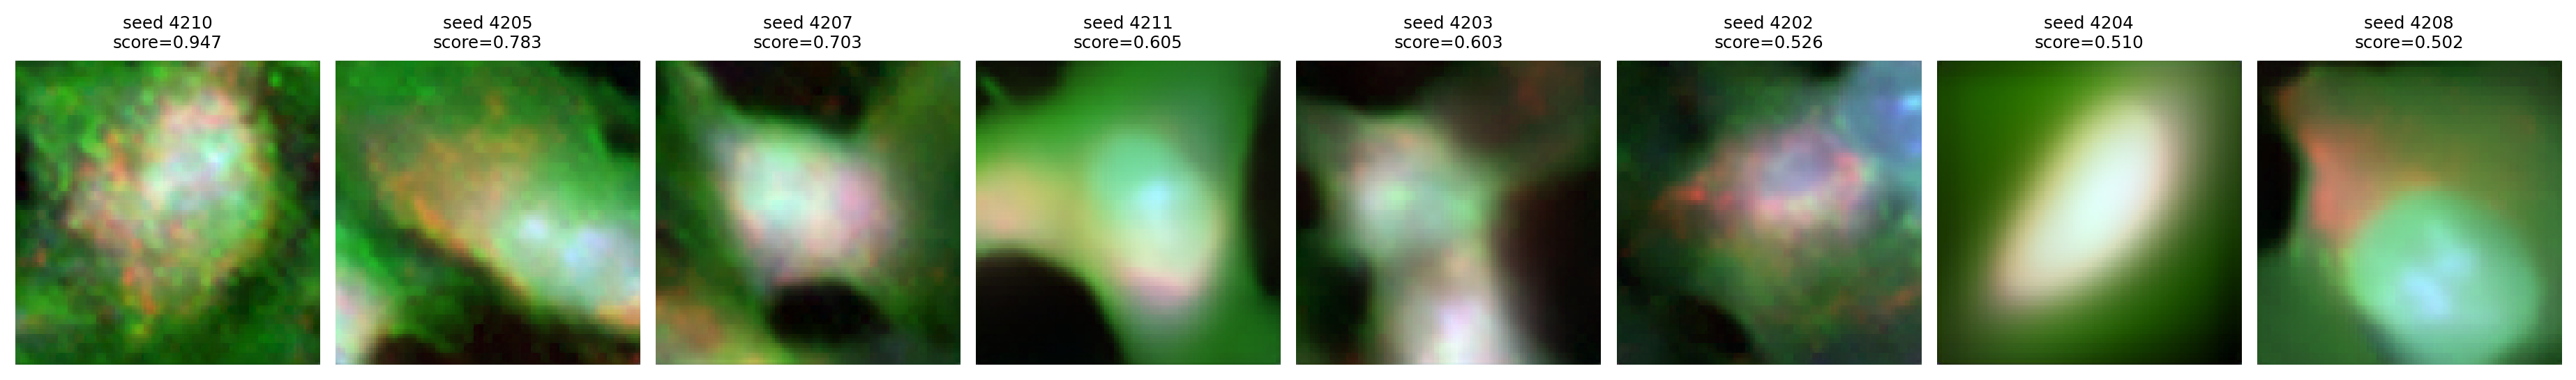


=== saved gallery ===
/root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/multiseed_selection/PDCD1_C5TermEx_top_seed_gallery.png
/root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed/multiseed_selection/PDCD1_C5TermEx_top_seed_gallery.svg

=== recommended seed ===
seed: 4210
sharpness_score: 0.9471903965688014
selected image: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_seed4210_merged_rgb.png
selected npy: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_seed4210_5channel.npy


In [6]:
from pathlib import Path
import os
import subprocess
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import shutil

# ============================================================
# Multi-seed visual selection for cross-species PDCD1 C5-TermEx
# predicted_perturbed morphology projection
# ============================================================

CASE_NAME = "PDCD1_C5-TermEx_predicted_perturbed"

CASE_DIR = Path(
    "/root/autodl-fs/project5/outputs/cross_species_to_morphology/"
    "03_morphdiff_generation/PDCD1_C5-TermEx_predicted_perturbed"
)

INPUT_NPY = CASE_DIR / "PDCD1_C5-TermEx_predicted_perturbed_morphdiff_input_12328.npy"

OUT_BASE = CASE_DIR / "multiseed_selection"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PANEL_DIR = Path(
    "/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels"
)
PANEL_DIR.mkdir(parents=True, exist_ok=True)

print("input:", INPUT_NPY, INPUT_NPY.exists())
if not INPUT_NPY.exists():
    raise FileNotFoundError(INPUT_NPY)

x = np.load(INPUT_NPY)
print("input shape:", x.shape, x.dtype, float(x.mean()), float(x.std()), float(x.min()), float(x.max()))

# ============================================================
# MorphDiff paths
# ============================================================

MORPHDIFF_ROOT = Path("/root/autodl-tmp/MorphDiff")
PYTHON = Path("/root/autodl-fs/project1/env/squidiff/bin/python")
SCRIPT = MORPHDIFF_ROOT / "scripts/gene2img_5c_pairseed.py"

PATCHED_CONFIG = Path(
    "/root/autodl-fs/project5/outputs/adamson_morphology_specificity/"
    "sec61a1_multiseed_visual_selection_fixed/morph_5c_gene12328_absolute_mvae.yaml"
)

MODEL_PATH = Path(
    "/root/autodl-fs/magic/JUMP_checkpoint_config/"
    "2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt"
)

for name, p in [
    ("python", PYTHON),
    ("script", SCRIPT),
    ("patched_config", PATCHED_CONFIG),
    ("model", MODEL_PATH),
]:
    print(name, p, p.exists())
    if not p.exists():
        raise FileNotFoundError(p)

# ============================================================
# 1. Generate multiple seeds
# ============================================================

STEPS = 500
SEEDS = list(range(4201, 4213))

env = os.environ.copy()
env["PYTHONPATH"] = str(MORPHDIFF_ROOT) + ":" + env.get("PYTHONPATH", "")
env["OMP_NUM_THREADS"] = "1"
env["MKL_NUM_THREADS"] = "1"
env["OPENBLAS_NUM_THREADS"] = "1"
env["NUMEXPR_NUM_THREADS"] = "1"
env["CUDA_VISIBLE_DEVICES"] = "0"

run_records = []

for seed in SEEDS:
    run_dir = OUT_BASE / f"steps{STEPS}_seed{seed}_scale1"
    run_dir.mkdir(parents=True, exist_ok=True)

    log_dir = run_dir / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    output_name = f"{CASE_NAME}_steps{STEPS}_seed{seed}_scale1.npy"
    log_file = log_dir / f"run_{CASE_NAME}_steps{STEPS}_seed{seed}_scale1.log"

    img = run_dir / "images0.png"
    npy_out = run_dir / output_name

    if img.exists() and npy_out.exists():
        print(f"[SKIP] seed {seed}: already exists")
        ret_code = 0
    else:
        cmd = [
            str(PYTHON),
            str(SCRIPT),
            "--gene_path", str(INPUT_NPY),
            "--outdir", str(run_dir),
            "--output_name", output_name,
            "--ddim_steps", str(STEPS),
            "--seed", str(seed),
            "--batch_size", "1",
            "--scale", "1.0",
            "--H", "128",
            "--W", "128",
            "--config_path", str(PATCHED_CONFIG),
            "--model_path", str(MODEL_PATH),
        ]

        print(f"\n=== running seed {seed} ===")
        print(" ".join(cmd))

        with open(log_file, "w") as f:
            ret = subprocess.run(
                cmd,
                cwd=str(MORPHDIFF_ROOT),
                env=env,
                text=True,
                stdout=f,
                stderr=subprocess.STDOUT,
            )

        ret_code = ret.returncode
        print("return code:", ret_code)

    run_records.append({
        "seed": seed,
        "run_dir": str(run_dir),
        "returncode": ret_code,
        "image": str(img),
        "npy": str(npy_out),
        "image_exists": img.exists(),
        "npy_exists": npy_out.exists(),
        "log": str(log_file),
    })

run_df = pd.DataFrame(run_records)
run_csv = OUT_BASE / "PDCD1_C5TermEx_multiseed_generation_runs.csv"
run_df.to_csv(run_csv, index=False)

print("\n=== generation summary ===")
print(run_df[["seed", "returncode", "image_exists", "npy_exists", "run_dir"]])
print("saved:", run_csv)

if not run_df["image_exists"].any():
    raise RuntimeError("No images were generated.")

# ============================================================
# 2. Sharpness scoring
# ============================================================

def laplacian_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def contrast_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return float(gray.std())

def edge_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return float(np.mean(np.sqrt(gx**2 + gy**2)))

def saturation_ratio(img_rgb):
    arr = img_rgb.astype(np.float32)
    return float(((arr <= 2) | (arr >= 253)).mean())

score_rows = []

for _, r in run_df.iterrows():
    img_path = Path(r["image"])
    npy_path = Path(r["npy"])

    if not img_path.exists():
        continue

    img = np.array(Image.open(img_path).convert("RGB"))

    score_rows.append({
        "seed": int(r["seed"]),
        "image": str(img_path),
        "npy": str(npy_path),
        "run_dir": r["run_dir"],
        "laplacian_var": laplacian_score(img),
        "edge_strength": edge_score(img),
        "contrast_std": contrast_score(img),
        "mean_intensity": float(img.mean()),
        "std_intensity": float(img.std()),
        "saturation_ratio": saturation_ratio(img),
    })

score_df = pd.DataFrame(score_rows)

for col in ["laplacian_var", "edge_strength", "contrast_std"]:
    max_val = score_df[col].max()
    score_df[col + "_norm"] = score_df[col] / max_val if max_val > 0 else 0

score_df["raw_sharpness_score"] = (
    0.50 * score_df["laplacian_var_norm"] +
    0.30 * score_df["edge_strength_norm"] +
    0.20 * score_df["contrast_std_norm"]
)

score_df["sharpness_score"] = score_df["raw_sharpness_score"] * (
    1 - 0.35 * score_df["saturation_ratio"]
)

score_df = score_df.sort_values("sharpness_score", ascending=False).reset_index(drop=True)

score_csv = OUT_BASE / "PDCD1_C5TermEx_seed_sharpness_ranking.csv"
score_df.to_csv(score_csv, index=False)

print("\n=== top seeds by sharpness ===")
print(score_df.head(12)[[
    "seed",
    "sharpness_score",
    "laplacian_var",
    "edge_strength",
    "contrast_std",
    "saturation_ratio",
    "image",
]])
print("saved:", score_csv)

# ============================================================
# 3. Gallery
# ============================================================

n_show = min(8, len(score_df))

fig, axes = plt.subplots(
    1,
    n_show,
    figsize=(2.1 * n_show, 2.3),
    dpi=220
)

if n_show == 1:
    axes = [axes]

for i in range(n_show):
    row = score_df.iloc[i]
    img = np.array(Image.open(row["image"]).convert("RGB"))

    axes[i].imshow(img)
    axes[i].set_title(
        f"seed {int(row['seed'])}\nscore={row['sharpness_score']:.3f}",
        fontsize=8
    )
    axes[i].axis("off")

plt.tight_layout()

gallery_png = OUT_BASE / "PDCD1_C5TermEx_top_seed_gallery.png"
gallery_svg = OUT_BASE / "PDCD1_C5TermEx_top_seed_gallery.svg"

fig.savefig(gallery_png, dpi=300, bbox_inches="tight")
fig.savefig(gallery_svg, bbox_inches="tight")
plt.show()
plt.close(fig)

print("\n=== saved gallery ===")
print(gallery_png)
print(gallery_svg)

# ============================================================
# 4. Copy best seed result
# ============================================================

best = score_df.iloc[0]
best_seed = int(best["seed"])

best_img = Path(best["image"])
best_npy = Path(best["npy"])

selected_img = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{best_seed}_merged_rgb.png"
selected_npy = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{best_seed}_5channel.npy"

shutil.copy2(best_img, selected_img)
shutil.copy2(best_npy, selected_npy)

print("\n=== recommended seed ===")
print("seed:", best_seed)
print("sharpness_score:", float(best["sharpness_score"]))
print("selected image:", selected_img)
print("selected npy:", selected_npy)

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import json

# ============================================================
# Final clean panel for cross-species morphology projection
# Case: PDCD1 | C5-TermEx | predicted_perturbed | selected seed 4210
# ============================================================

CASE_NAME = "PDCD1_C5TermEx_predicted"
SEED = 4210

PANEL_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels")
PANEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_PATH = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_merged_rgb.png"
NPY_PATH = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_5channel.npy"

print("image:", IMG_PATH, IMG_PATH.exists())
print("npy:", NPY_PATH, NPY_PATH.exists())

if not IMG_PATH.exists():
    raise FileNotFoundError(IMG_PATH)
if not NPY_PATH.exists():
    raise FileNotFoundError(NPY_PATH)

rgb = np.array(Image.open(IMG_PATH).convert("RGB"))
arr = np.load(NPY_PATH).astype(np.float32)

print("rgb:", rgb.shape, rgb.dtype, rgb.min(), rgb.max(), rgb.mean(), rgb.std())
print("arr:", arr.shape, arr.dtype, arr.min(), arr.max(), arr.mean(), arr.std())

if arr.shape != (1, 128, 128, 5):
    raise ValueError(f"Expected shape (1,128,128,5), got {arr.shape}")

img5 = arr[0]

# ============================================================
# Channel display normalization

# ============================================================

ch_low = np.percentile(img5, 1, axis=(0, 1))
ch_high = np.percentile(img5, 99, axis=(0, 1))
ch_high = np.where(ch_high <= ch_low + 1e-6, ch_low + 1.0, ch_high)

print("\nchannel scaling:")
for c in range(5):
    print(f"ch{c}: low={ch_low[c]:.3f}, high={ch_high[c]:.3f}")

def norm_ch(img5, c, gamma=0.85):
    x = (img5[:, :, c] - ch_low[c]) / (ch_high[c] - ch_low[c])
    x = np.clip(x, 0, 1)
    x = np.power(x, gamma)
    return x

# ============================================================
# Nature-like style
# ============================================================

MM_TO_INCH = 1 / 25.4

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 600,
})

# ============================================================
# 1. Clean version for the composite manuscript figure
# ============================================================

fig = plt.figure(figsize=(165 * MM_TO_INCH, 34 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

# merged RGB
ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

# arrow
ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.50,
    0.50,
    "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

# five channels
for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.05, top=0.82)

out_clean_png = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_projection_clean.png"
out_clean_svg = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_projection_clean.svg"
out_clean_pdf = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_projection_clean.pdf"

fig.savefig(out_clean_png)
fig.savefig(out_clean_svg)
fig.savefig(out_clean_pdf)
plt.close(fig)

print("\n=== saved clean panel ===")
print(out_clean_png)
print(out_clean_svg)
print(out_clean_pdf)

# ============================================================
# 2. Titled versin
# ============================================================

fig = plt.figure(figsize=(165 * MM_TO_INCH, 45 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.50,
    0.50,
    "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.suptitle(
    "Cross-species transcriptome-derived morphology projection",
    fontsize=8.8,
    fontweight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.025,
    "PDCD1 perturbation in C5-TermEx mouse TIL state; generated from predicted post-perturbation transcriptome.",
    ha="center",
    va="bottom",
    fontsize=5.4,
    color="#333333",
)

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.17, top=0.76)

out_png = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_projection.png"
out_svg = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_projection.svg"
out_pdf = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_predicted_seed{SEED}_projection.pdf"

fig.savefig(out_png)
fig.savefig(out_svg)
fig.savefig(out_pdf)
plt.close(fig)

print("\n=== saved titled panel ===")
print(out_png)
print(out_svg)
print(out_pdf)

# ============================================================
# 3
# ============================================================

CH_DIR = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_seed{SEED}_channels"
CH_DIR.mkdir(parents=True, exist_ok=True)

records = []

for c in range(5):
    x = norm_ch(img5, c)
    p = CH_DIR / f"PDCD1_C5TermEx_predicted_seed{SEED}_ch{c}.png"
    Image.fromarray((x * 255).astype(np.uint8)).save(p)

    records.append({
        "case": CASE_NAME,
        "seed": SEED,
        "channel": f"ch{c}",
        "png": str(p),
        "scaling_low": float(ch_low[c]),
        "scaling_high": float(ch_high[c]),
    })

channel_df = pd.DataFrame(records)
channel_csv = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_seed{SEED}_channel_files.csv"
channel_df.to_csv(channel_csv, index=False)

print("\n=== saved channel files ===")
print(channel_csv)
print(channel_df)

# ============================================================
# 4. summary
# ============================================================

summary = {
    "case": "PDCD1_C5-TermEx_predicted_perturbed",
    "perturbation": "PDCD1",
    "context": "C5-TermEx",
    "source": "predicted_perturbed",
    "selected_seed": SEED,
    "selection_reason": "Highest sharpness score among seeds 4201-4212",
    "generated_rgb": str(IMG_PATH),
    "generated_5channel_npy": str(NPY_PATH),
    "outputs": {
        "clean_png": str(out_clean_png),
        "clean_svg": str(out_clean_svg),
        "clean_pdf": str(out_clean_pdf),
        "png": str(out_png),
        "svg": str(out_svg),
        "pdf": str(out_pdf),
        "channel_csv": str(channel_csv),
    },
    "caption_safe": (
        "Cross-species transcriptome-derived morphology projection for PDCD1 perturbation "
        "in the C5-TermEx mouse TIL state. The image is generated from the predicted post-perturbation "
        "transcriptome and should be interpreted as a downstream phenotype projection rather than "
        "experimentally observed mouse microscopy."
    ),
}

summary_path = PANEL_DIR / f"cross_species_PDCD1_C5TermEx_seed{SEED}_projection_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("\n=== saved summary ===")
print(summary_path)

image: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_seed4210_merged_rgb.png True
npy: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_seed4210_5channel.npy True
rgb: (128, 128, 3) uint8 0 255 89.77630615234375 60.49000815465974
arr: (1, 128, 128, 5) float32 0.0 255.0 70.79026 67.964066

channel scaling:
ch0: low=6.000, high=242.000
ch1: low=27.000, high=254.000
ch2: low=0.000, high=173.000
ch3: low=0.000, high=203.000
ch4: low=0.000, high=191.000

=== saved clean panel ===
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_seed4210_projection_clean.png
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_seed4210_projection_clean.svg
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_PDCD1_C5TermEx_predicted_seed4

In [ ]:
from pathlib import Path
import os
import subprocess
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import shutil
import json

# ============================================================
# Cross-species morphology projection for another perturbation
# Case: ARID1A | C5-TermEx | predicted_perturbed
# Steps:
#   1. Select ARID1A C5-TermEx predicted row from aligned 42 x 12328 matrix
#   2. Run MorphDiff multi-seed generation
#   3. Rank by sharpness
#   4. Save best merged RGB + 5-channel panel
# ============================================================

CASE_PERT = "ARID1A"
CASE_CONTEXT = "C5-TermEx"
CASE_SOURCE = "predicted_perturbed"

CASE_NAME = f"{CASE_PERT}_{CASE_CONTEXT}_{CASE_SOURCE}"
CASE_NAME_SAFE = CASE_NAME.replace("|", "_").replace("/", "_")

# ============================================================
# 0. Paths
# ============================================================

IN_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/02_morphdiff_input")

MATRIX_PATH = IN_DIR / "cross_species_control_true_pred_morphdiff_12328.npy"
META_PATH = IN_DIR / "cross_species_control_true_pred_morphdiff_12328_metadata.csv"

GEN_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation")
CASE_DIR = GEN_DIR / CASE_NAME_SAFE
CASE_DIR.mkdir(parents=True, exist_ok=True)

PANEL_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels")
PANEL_DIR.mkdir(parents=True, exist_ok=True)

print("matrix:", MATRIX_PATH, MATRIX_PATH.exists())
print("meta:", META_PATH, META_PATH.exists())

if not MATRIX_PATH.exists():
    raise FileNotFoundError(MATRIX_PATH)
if not META_PATH.exists():
    raise FileNotFoundError(META_PATH)

# ============================================================
# 1. Load aligned MorphDiff input matrix and metadata
# ============================================================

X = np.load(MATRIX_PATH).astype(np.float32)
meta = pd.read_csv(META_PATH)

print("\n=== loaded ===")
print("X:", X.shape, X.dtype, float(X.mean()), float(X.std()), float(X.min()), float(X.max()))
print("meta:", meta.shape)
print(meta.head())

# ============================================================
# 2. Select ARID1A | C5-TermEx | predicted_perturbed
# ============================================================

sub = meta[
    (meta["perturbation"].astype(str) == CASE_PERT) &
    (meta["context"].astype(str) == CASE_CONTEXT) &
    (meta["source"].astype(str) == CASE_SOURCE)
].copy()

print("\n=== selected row ===")
print(sub)

if sub.shape[0] != 1:
    print("\n[DEBUG] available rows for this perturbation/context:")
    print(meta[
        (meta["perturbation"].astype(str) == CASE_PERT) &
        (meta["context"].astype(str) == CASE_CONTEXT)
    ])
    raise RuntimeError("selected row is not unique")

row_index = int(sub.iloc[0]["morphdiff_row_index"])
case_vec = X[row_index:row_index + 1].astype(np.float32)

print("\nselected row_index:", row_index)
print("case_vec:", case_vec.shape, case_vec.dtype, float(case_vec.mean()), float(case_vec.std()), float(case_vec.min()), float(case_vec.max()))

INPUT_NPY = CASE_DIR / f"{CASE_NAME_SAFE}_morphdiff_input_12328.npy"
INPUT_META = CASE_DIR / f"{CASE_NAME_SAFE}_morphdiff_input_metadata.csv"

np.save(INPUT_NPY, case_vec)
sub.to_csv(INPUT_META, index=False)

print("\n=== saved selected MorphDiff input ===")
print(INPUT_NPY)
print(INPUT_META)

# ============================================================
# 3. MorphDiff paths
# ============================================================

MORPHDIFF_ROOT = Path("/root/autodl-tmp/MorphDiff")
PYTHON = Path("/root/autodl-fs/project1/env/squidiff/bin/python")
SCRIPT = MORPHDIFF_ROOT / "scripts/gene2img_5c_pairseed.py"

PATCHED_CONFIG = Path(
    "/root/autodl-fs/project5/outputs/adamson_morphology_specificity/"
    "sec61a1_multiseed_visual_selection_fixed/morph_5c_gene12328_absolute_mvae.yaml"
)

MODEL_PATH = Path(
    "/root/autodl-fs/magic/JUMP_checkpoint_config/"
    "2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt"
)

for name, p in [
    ("python", PYTHON),
    ("script", SCRIPT),
    ("patched_config", PATCHED_CONFIG),
    ("model", MODEL_PATH),
    ("input", INPUT_NPY),
]:
    print(name, p, p.exists())
    if not p.exists():
        raise FileNotFoundError(p)

# ============================================================
# 4. Multi-seed generation
# ============================================================

STEPS = 500
SEEDS = list(range(4301, 4313))

OUT_BASE = CASE_DIR / "multiseed_selection"
OUT_BASE.mkdir(parents=True, exist_ok=True)

env = os.environ.copy()
env["PYTHONPATH"] = str(MORPHDIFF_ROOT) + ":" + env.get("PYTHONPATH", "")
env["OMP_NUM_THREADS"] = "1"
env["MKL_NUM_THREADS"] = "1"
env["OPENBLAS_NUM_THREADS"] = "1"
env["NUMEXPR_NUM_THREADS"] = "1"
env["CUDA_VISIBLE_DEVICES"] = "0"

run_records = []

for seed in SEEDS:
    run_dir = OUT_BASE / f"steps{STEPS}_seed{seed}_scale1"
    run_dir.mkdir(parents=True, exist_ok=True)

    log_dir = run_dir / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    output_name = f"{CASE_NAME_SAFE}_steps{STEPS}_seed{seed}_scale1.npy"
    log_file = log_dir / f"run_{CASE_NAME_SAFE}_steps{STEPS}_seed{seed}_scale1.log"

    img_path = run_dir / "images0.png"
    npy_path = run_dir / output_name

    if img_path.exists() and npy_path.exists():
        print(f"[SKIP] seed {seed}: already exists")
        ret_code = 0
    else:
        cmd = [
            str(PYTHON),
            str(SCRIPT),
            "--gene_path", str(INPUT_NPY),
            "--outdir", str(run_dir),
            "--output_name", output_name,
            "--ddim_steps", str(STEPS),
            "--seed", str(seed),
            "--batch_size", "1",
            "--scale", "1.0",
            "--H", "128",
            "--W", "128",
            "--config_path", str(PATCHED_CONFIG),
            "--model_path", str(MODEL_PATH),
        ]

        print(f"\n=== running seed {seed} ===")
        print(" ".join(cmd))

        with open(log_file, "w") as f:
            ret = subprocess.run(
                cmd,
                cwd=str(MORPHDIFF_ROOT),
                env=env,
                text=True,
                stdout=f,
                stderr=subprocess.STDOUT,
            )

        ret_code = ret.returncode
        print("return code:", ret_code)

    run_records.append({
        "perturbation": CASE_PERT,
        "context": CASE_CONTEXT,
        "source": CASE_SOURCE,
        "seed": seed,
        "run_dir": str(run_dir),
        "returncode": ret_code,
        "image": str(img_path),
        "npy": str(npy_path),
        "image_exists": img_path.exists(),
        "npy_exists": npy_path.exists(),
        "log": str(log_file),
    })

run_df = pd.DataFrame(run_records)

run_csv = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_multiseed_generation_runs.csv"
run_df.to_csv(run_csv, index=False)

print("\n=== generation summary ===")
print(run_df[["seed", "returncode", "image_exists", "npy_exists", "run_dir"]])
print("saved:", run_csv)

if not run_df["image_exists"].any():
    raise RuntimeError("No ARID1A images were generated.")

# ============================================================
# 5. Sharpness scoring
# ============================================================

def laplacian_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def contrast_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return float(gray.std())

def edge_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return float(np.mean(np.sqrt(gx**2 + gy**2)))

def saturation_ratio(img_rgb):
    arr = img_rgb.astype(np.float32)
    return float(((arr <= 2) | (arr >= 253)).mean())

score_rows = []

for _, r in run_df.iterrows():
    img_path = Path(r["image"])
    npy_path = Path(r["npy"])

    if not img_path.exists():
        continue

    img = np.array(Image.open(img_path).convert("RGB"))

    score_rows.append({
        "perturbation": CASE_PERT,
        "context": CASE_CONTEXT,
        "source": CASE_SOURCE,
        "seed": int(r["seed"]),
        "image": str(img_path),
        "npy": str(npy_path),
        "run_dir": r["run_dir"],
        "laplacian_var": laplacian_score(img),
        "edge_strength": edge_score(img),
        "contrast_std": contrast_score(img),
        "mean_intensity": float(img.mean()),
        "std_intensity": float(img.std()),
        "saturation_ratio": saturation_ratio(img),
    })

score_df = pd.DataFrame(score_rows)

for col in ["laplacian_var", "edge_strength", "contrast_std"]:
    max_val = score_df[col].max()
    score_df[col + "_norm"] = score_df[col] / max_val if max_val > 0 else 0

score_df["raw_sharpness_score"] = (
    0.50 * score_df["laplacian_var_norm"] +
    0.30 * score_df["edge_strength_norm"] +
    0.20 * score_df["contrast_std_norm"]
)

score_df["sharpness_score"] = score_df["raw_sharpness_score"] * (
    1 - 0.35 * score_df["saturation_ratio"]
)

score_df = score_df.sort_values("sharpness_score", ascending=False).reset_index(drop=True)

score_csv = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_seed_sharpness_ranking.csv"
score_df.to_csv(score_csv, index=False)

print("\n=== top seeds by sharpness ===")
print(score_df.head(12)[[
    "seed",
    "sharpness_score",
    "laplacian_var",
    "edge_strength",
    "contrast_std",
    "saturation_ratio",
    "image",
]])
print("saved:", score_csv)

# ============================================================
# 6. Gallery
# ============================================================

n_show = min(8, len(score_df))

fig, axes = plt.subplots(
    1,
    n_show,
    figsize=(2.1 * n_show, 2.3),
    dpi=220
)

if n_show == 1:
    axes = [axes]

for i in range(n_show):
    row = score_df.iloc[i]
    img = np.array(Image.open(row["image"]).convert("RGB"))

    axes[i].imshow(img)
    axes[i].set_title(
        f"seed {int(row['seed'])}\nscore={row['sharpness_score']:.3f}",
        fontsize=8
    )
    axes[i].axis("off")

plt.tight_layout()

gallery_png = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_top_seed_gallery.png"
gallery_svg = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_top_seed_gallery.svg"

fig.savefig(gallery_png, dpi=300, bbox_inches="tight")
fig.savefig(gallery_svg, bbox_inches="tight")
plt.show()
plt.close(fig)

print("\n=== saved gallery ===")
print(gallery_png)
print(gallery_svg)

# ============================================================
# 7. Copy best seed result to panel dir
# ============================================================

best = score_df.iloc[0]
best_seed = int(best["seed"])

best_img = Path(best["image"])
best_npy = Path(best["npy"])

selected_img = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_merged_rgb.png"
selected_npy = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_5channel.npy"

shutil.copy2(best_img, selected_img)
shutil.copy2(best_npy, selected_npy)

print("\n=== recommended seed ===")
print("perturbation:", CASE_PERT)
print("context:", CASE_CONTEXT)
print("seed:", best_seed)
print("sharpness_score:", float(best["sharpness_score"]))
print("selected image:", selected_img)
print("selected npy:", selected_npy)

# ============================================================
# 8. Generate clean merged + 5-channel panel for best seed
# ============================================================

rgb = np.array(Image.open(selected_img).convert("RGB"))
arr = np.load(selected_npy).astype(np.float32)

print("\n=== selected output check ===")
print("rgb:", rgb.shape, rgb.dtype, rgb.min(), rgb.max(), rgb.mean(), rgb.std())
print("arr:", arr.shape, arr.dtype, arr.min(), arr.max(), arr.mean(), arr.std())

if arr.shape != (1, 128, 128, 5):
    raise ValueError(f"Expected shape (1,128,128,5), got {arr.shape}")

img5 = arr[0]

ch_low = np.percentile(img5, 1, axis=(0, 1))
ch_high = np.percentile(img5, 99, axis=(0, 1))
ch_high = np.where(ch_high <= ch_low + 1e-6, ch_low + 1.0, ch_high)

print("\nchannel scaling:")
for c in range(5):
    print(f"ch{c}: low={ch_low[c]:.3f}, high={ch_high[c]:.3f}")

def norm_ch(img5, c, gamma=0.85):
    x = (img5[:, :, c] - ch_low[c]) / (ch_high[c] - ch_low[c])
    x = np.clip(x, 0, 1)
    x = np.power(x, gamma)
    return x

MM_TO_INCH = 1 / 25.4

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 600,
})

fig = plt.figure(figsize=(165 * MM_TO_INCH, 34 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.50,
    0.50,
    "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.05, top=0.82)

out_clean_png = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_projection_clean.png"
out_clean_svg = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_projection_clean.svg"
out_clean_pdf = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_projection_clean.pdf"

fig.savefig(out_clean_png)
fig.savefig(out_clean_svg)
fig.savefig(out_clean_pdf)
plt.close(fig)

print("\n=== saved clean panel ===")
print(out_clean_png)
print(out_clean_svg)
print(out_clean_pdf)

# Titled version
fig = plt.figure(figsize=(165 * MM_TO_INCH, 45 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.50,
    0.50,
    "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.suptitle(
    "Cross-species transcriptome-derived morphology projection",
    fontsize=8.8,
    fontweight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.025,
    f"{CASE_PERT} perturbation in {CASE_CONTEXT} mouse TIL state; generated from predicted post-perturbation transcriptome.",
    ha="center",
    va="bottom",
    fontsize=5.4,
    color="#333333",
)

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.17, top=0.76)

out_png = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_projection.png"
out_svg = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_projection.svg"
out_pdf = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_projection.pdf"

fig.savefig(out_png)
fig.savefig(out_svg)
fig.savefig(out_pdf)
plt.close(fig)

print("\n=== saved titled panel ===")
print(out_png)
print(out_svg)
print(out_pdf)

# Channel files
CH_DIR = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_seed{best_seed}_channels"
CH_DIR.mkdir(parents=True, exist_ok=True)

records = []

for c in range(5):
    x = norm_ch(img5, c)
    p = CH_DIR / f"{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_ch{c}.png"
    Image.fromarray((x * 255).astype(np.uint8)).save(p)

    records.append({
        "case": CASE_NAME_SAFE,
        "perturbation": CASE_PERT,
        "context": CASE_CONTEXT,
        "source": CASE_SOURCE,
        "seed": best_seed,
        "channel": f"ch{c}",
        "png": str(p),
        "scaling_low": float(ch_low[c]),
        "scaling_high": float(ch_high[c]),
    })

channel_df = pd.DataFrame(records)
channel_csv = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_seed{best_seed}_channel_files.csv"
channel_df.to_csv(channel_csv, index=False)

print("\n=== saved channel files ===")
print(channel_csv)

summary = {
    "case": CASE_NAME_SAFE,
    "perturbation": CASE_PERT,
    "context": CASE_CONTEXT,
    "source": CASE_SOURCE,
    "selected_seed": best_seed,
    "selection_reason": "Highest sharpness score among seeds 4301-4312",
    "input_npy": str(INPUT_NPY),
    "selected_rgb": str(selected_img),
    "selected_5channel_npy": str(selected_npy),
    "ranking_csv": str(score_csv),
    "gallery_png": str(gallery_png),
    "outputs": {
        "clean_png": str(out_clean_png),
        "clean_svg": str(out_clean_svg),
        "clean_pdf": str(out_clean_pdf),
        "png": str(out_png),
        "svg": str(out_svg),
        "pdf": str(out_pdf),
        "channel_csv": str(channel_csv),
    },
    "caption_safe": (
        f"Cross-species transcriptome-derived morphology projection for {CASE_PERT} perturbation "
        f"in the {CASE_CONTEXT} mouse TIL state. The generated image is based on the predicted "
        "post-perturbation transcriptome and should be interpreted as a downstream phenotype projection "
        "rather than experimentally observed mouse microscopy."
    ),
}

summary_path = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_seed{best_seed}_projection_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("\n=== saved summary ===")
print(summary_path)

matrix: /root/autodl-fs/project5/outputs/cross_species_to_morphology/02_morphdiff_input/cross_species_control_true_pred_morphdiff_12328.npy True
meta: /root/autodl-fs/project5/outputs/cross_species_to_morphology/02_morphdiff_input/cross_species_control_true_pred_morphdiff_12328_metadata.csv True

=== loaded ===
X: (42, 12328) float32 -0.08494316786527634 0.7487590312957764 -0.6227006316184998 4.0
meta: (42, 12)
   row_index              key perturbation   context               source  \
0          0  ARID1A|C1-S1pr1       ARID1A  C1-S1pr1              control   
1          1  ARID1A|C1-S1pr1       ARID1A  C1-S1pr1  predicted_perturbed   
2          2  ARID1A|C1-S1pr1       ARID1A  C1-S1pr1       true_perturbed   
3          3    ARID1A|C2-ISG       ARID1A    C2-ISG              control   
4          4    ARID1A|C2-ISG       ARID1A    C2-ISG  predicted_perturbed   

   n_cells expr_layer  morphdiff_row_index  n_source_genes  n_morphdiff_genes  \
0     6008      log1p                    

In [1]:
from pathlib import Path
import subprocess
import os
import signal
import time

LOG_FILE = Path(
    "/root/autodl-fs/project5/outputs/cross_species_to_morphology/"
    "03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed/"
    "multiseed_selection/steps500_seed4301_scale1/logs/"
    "run_ARID1A_C5-TermEx_predicted_perturbed_steps500_seed4301_scale1.log"
)

RUN_DIR = Path(
    "/root/autodl-fs/project5/outputs/cross_species_to_morphology/"
    "03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed/"
    "multiseed_selection/steps500_seed4301_scale1"
)

print("=== log exists ===")
print(LOG_FILE, LOG_FILE.exists())

if LOG_FILE.exists():
    print("\n=== log tail ===")
    txt = LOG_FILE.read_text(errors="ignore").splitlines()
    print("\n".join(txt[-120:]))
else:
    print("log file not found")

print("\n=== output files ===")
if RUN_DIR.exists():
    for p in sorted(RUN_DIR.rglob("*")):
        if p.is_file():
            print(p.relative_to(RUN_DIR), p.stat().st_size)
else:
    print("RUN_DIR not found:", RUN_DIR)

print("\n=== gene2img processes ===")
ps = subprocess.run(
    "ps -ef | grep gene2img_5c_pairseed.py | grep -v grep",
    shell=True,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
print(ps.stdout if ps.stdout.strip() else "no gene2img process")

print("\n=== nvidia-smi ===")
smi = subprocess.run(
    "nvidia-smi",
    shell=True,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
print(smi.stdout)

=== log exists ===
/root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed/multiseed_selection/steps500_seed4301_scale1/logs/run_ARID1A_C5-TermEx_predicted_perturbed_steps500_seed4301_scale1.log True

=== log tail ===

DDIM Sampler:  67%|██████▋   | 337/500 [00:16<00:05, 28.68it/s]

DDIM Sampler:  68%|██████▊   | 340/500 [00:16<00:05, 28.72it/s]

DDIM Sampler:  69%|██████▊   | 343/500 [00:16<00:05, 28.78it/s]

DDIM Sampler:  69%|██████▉   | 346/500 [00:16<00:05, 28.88it/s]

DDIM Sampler:  70%|██████▉   | 349/500 [00:16<00:05, 28.78it/s]

DDIM Sampler:  70%|███████   | 352/500 [00:17<00:05, 28.83it/s]

DDIM Sampler:  71%|███████   | 355/500 [00:17<00:05, 28.89it/s]

DDIM Sampler:  72%|███████▏  | 358/500 [00:17<00:04, 28.93it/s]

DDIM Sampler:  72%|███████▏  | 361/500 [00:17<00:04, 28.93it/s]

DDIM Sampler:  73%|███████▎  | 364/500 [00:17<00:04, 28.85it/s]

DDIM Sampler:  73%|███████▎  | 367/500 [00:17<00:04, 28.90it/s]



input: /root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed/ARID1A_C5-TermEx_predicted_perturbed_morphdiff_input_12328.npy True
script: /root/autodl-tmp/MorphDiff/scripts/gene2img_5c_pairseed.py True
config: /root/autodl-fs/project5/outputs/adamson_morphology_specificity/sec61a1_multiseed_visual_selection_fixed/morph_5c_gene12328_absolute_mvae.yaml True
model: /root/autodl-fs/magic/JUMP_checkpoint_config/2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt True
input shape: (1, 12328) float32 0.0937575027346611 0.9621549248695374 -0.6227006316184998 4.0
[SKIP] seed 4301: already exists
[SKIP] seed 4302: already exists
[SKIP] seed 4303: already exists
[SKIP] seed 4304: already exists
[SKIP] seed 4305: already exists
[SKIP] seed 4306: already exists
[SKIP] seed 4307: already exists
[SKIP] seed 4308: already exists
[SKIP] seed 4309: already exists
[SKIP] seed 4310: already exists
[SKIP] seed 4311: already exists
[SKIP] seed

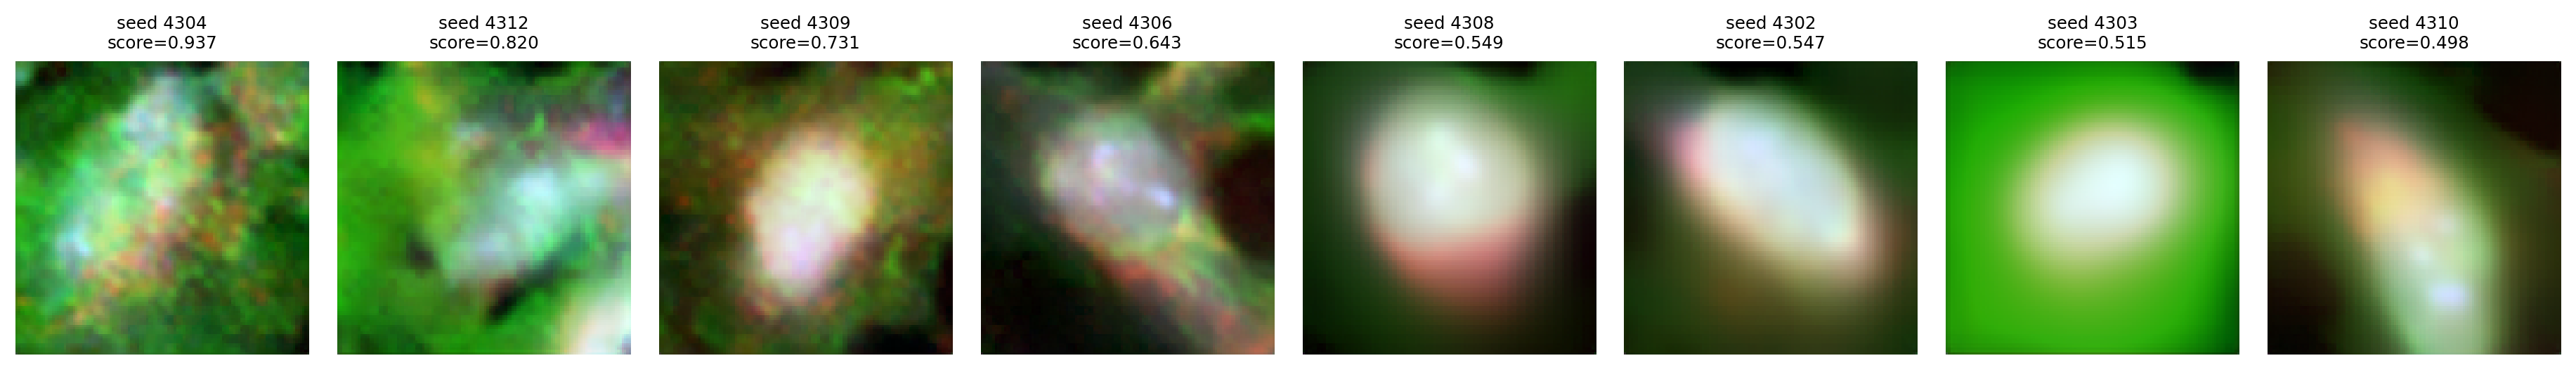


=== saved gallery ===
/root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed/multiseed_selection/ARID1A_C5-TermEx_top_seed_gallery_resume.png
/root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed/multiseed_selection/ARID1A_C5-TermEx_top_seed_gallery_resume.svg

=== recommended seed ===
perturbation: ARID1A
context: C5-TermEx
seed: 4304
sharpness_score: 0.9372435963923221
selected image: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_ARID1A_C5-TermEx_predicted_seed4304_merged_rgb.png
selected npy: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_ARID1A_C5-TermEx_predicted_seed4304_5channel.npy
ranking csv: /root/autodl-fs/project5/outputs/cross_species_to_morphology/03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed/multiseed_selection/ARID1A_C5-TermEx_seed_sharpness_ran

In [2]:
from pathlib import Path
import os
import subprocess
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import shutil

# ============================================================
# Resume ARID1A | C5-TermEx multi-seed generation + ranking
# Skip existing seed 4301 automatically
# ============================================================

CASE_PERT = "ARID1A"
CASE_CONTEXT = "C5-TermEx"
CASE_SOURCE = "predicted_perturbed"
CASE_NAME_SAFE = "ARID1A_C5-TermEx_predicted_perturbed"

CASE_DIR = Path(
    "/root/autodl-fs/project5/outputs/cross_species_to_morphology/"
    "03_morphdiff_generation/ARID1A_C5-TermEx_predicted_perturbed"
)

INPUT_NPY = CASE_DIR / "ARID1A_C5-TermEx_predicted_perturbed_morphdiff_input_12328.npy"

OUT_BASE = CASE_DIR / "multiseed_selection"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PANEL_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels")
PANEL_DIR.mkdir(parents=True, exist_ok=True)

MORPHDIFF_ROOT = Path("/root/autodl-tmp/MorphDiff")
PYTHON = Path("/root/autodl-fs/project1/env/squidiff/bin/python")
SCRIPT = MORPHDIFF_ROOT / "scripts/gene2img_5c_pairseed.py"

PATCHED_CONFIG = Path(
    "/root/autodl-fs/project5/outputs/adamson_morphology_specificity/"
    "sec61a1_multiseed_visual_selection_fixed/morph_5c_gene12328_absolute_mvae.yaml"
)

MODEL_PATH = Path(
    "/root/autodl-fs/magic/JUMP_checkpoint_config/"
    "2024-10-30T11-20-43_orf_ldm/checkpoints/last.ckpt"
)

print("input:", INPUT_NPY, INPUT_NPY.exists())
print("script:", SCRIPT, SCRIPT.exists())
print("config:", PATCHED_CONFIG, PATCHED_CONFIG.exists())
print("model:", MODEL_PATH, MODEL_PATH.exists())

for p in [INPUT_NPY, SCRIPT, PATCHED_CONFIG, MODEL_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

x = np.load(INPUT_NPY)
print("input shape:", x.shape, x.dtype, float(x.mean()), float(x.std()), float(x.min()), float(x.max()))

STEPS = 500
SEEDS = list(range(4301, 4313))

env = os.environ.copy()
env["PYTHONPATH"] = str(MORPHDIFF_ROOT) + ":" + env.get("PYTHONPATH", "")
env["OMP_NUM_THREADS"] = "1"
env["MKL_NUM_THREADS"] = "1"
env["OPENBLAS_NUM_THREADS"] = "1"
env["NUMEXPR_NUM_THREADS"] = "1"
env["CUDA_VISIBLE_DEVICES"] = "0"

run_records = []

for seed in SEEDS:
    run_dir = OUT_BASE / f"steps{STEPS}_seed{seed}_scale1"
    run_dir.mkdir(parents=True, exist_ok=True)

    log_dir = run_dir / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    output_name = f"{CASE_NAME_SAFE}_steps{STEPS}_seed{seed}_scale1.npy"
    log_file = log_dir / f"run_{CASE_NAME_SAFE}_steps{STEPS}_seed{seed}_scale1.log"

    img_path = run_dir / "images0.png"
    npy_path = run_dir / output_name

    if img_path.exists() and npy_path.exists():
        print(f"[SKIP] seed {seed}: already exists")
        ret_code = 0
    else:
        cmd = [
            str(PYTHON),
            str(SCRIPT),
            "--gene_path", str(INPUT_NPY),
            "--outdir", str(run_dir),
            "--output_name", output_name,
            "--ddim_steps", str(STEPS),
            "--seed", str(seed),
            "--batch_size", "1",
            "--scale", "1.0",
            "--H", "128",
            "--W", "128",
            "--config_path", str(PATCHED_CONFIG),
            "--model_path", str(MODEL_PATH),
        ]

        print(f"\n=== running seed {seed} ===")
        print(" ".join(cmd))

        try:
            with open(log_file, "w") as f:
                ret = subprocess.run(
                    cmd,
                    cwd=str(MORPHDIFF_ROOT),
                    env=env,
                    text=True,
                    stdout=f,
                    stderr=subprocess.STDOUT,
                    timeout=900,
                )
            ret_code = ret.returncode
            print("return code:", ret_code)

        except subprocess.TimeoutExpired:
            print(f"[TIMEOUT] seed {seed} exceeded 900 seconds")
            ret_code = 124

    run_records.append({
        "perturbation": CASE_PERT,
        "context": CASE_CONTEXT,
        "source": CASE_SOURCE,
        "seed": seed,
        "run_dir": str(run_dir),
        "returncode": ret_code,
        "image": str(img_path),
        "npy": str(npy_path),
        "image_exists": img_path.exists(),
        "npy_exists": npy_path.exists(),
        "log": str(log_file),
    })

run_df = pd.DataFrame(run_records)
run_csv = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_multiseed_generation_runs_resume.csv"
run_df.to_csv(run_csv, index=False)

print("\n=== generation summary ===")
print(run_df[["seed", "returncode", "image_exists", "npy_exists", "run_dir"]])
print("saved:", run_csv)

if not run_df["image_exists"].any():
    raise RuntimeError("No ARID1A images generated.")

# ============================================================
# Sharpness scoring
# ============================================================

def laplacian_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def contrast_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return float(gray.std())

def edge_score(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return float(np.mean(np.sqrt(gx**2 + gy**2)))

def saturation_ratio(img_rgb):
    arr = img_rgb.astype(np.float32)
    return float(((arr <= 2) | (arr >= 253)).mean())

score_rows = []

for _, r in run_df.iterrows():
    img_path = Path(r["image"])
    npy_path = Path(r["npy"])

    if not img_path.exists() or not npy_path.exists():
        continue

    img = np.array(Image.open(img_path).convert("RGB"))

    score_rows.append({
        "perturbation": CASE_PERT,
        "context": CASE_CONTEXT,
        "source": CASE_SOURCE,
        "seed": int(r["seed"]),
        "image": str(img_path),
        "npy": str(npy_path),
        "run_dir": r["run_dir"],
        "laplacian_var": laplacian_score(img),
        "edge_strength": edge_score(img),
        "contrast_std": contrast_score(img),
        "mean_intensity": float(img.mean()),
        "std_intensity": float(img.std()),
        "saturation_ratio": saturation_ratio(img),
    })

score_df = pd.DataFrame(score_rows)

for col in ["laplacian_var", "edge_strength", "contrast_std"]:
    max_val = score_df[col].max()
    score_df[col + "_norm"] = score_df[col] / max_val if max_val > 0 else 0

score_df["raw_sharpness_score"] = (
    0.50 * score_df["laplacian_var_norm"] +
    0.30 * score_df["edge_strength_norm"] +
    0.20 * score_df["contrast_std_norm"]
)

score_df["sharpness_score"] = score_df["raw_sharpness_score"] * (
    1 - 0.35 * score_df["saturation_ratio"]
)

score_df = score_df.sort_values("sharpness_score", ascending=False).reset_index(drop=True)

score_csv = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_seed_sharpness_ranking_resume.csv"
score_df.to_csv(score_csv, index=False)

print("\n=== top seeds by sharpness ===")
print(score_df.head(12)[[
    "seed",
    "sharpness_score",
    "laplacian_var",
    "edge_strength",
    "contrast_std",
    "saturation_ratio",
    "image",
]])
print("saved:", score_csv)

# ============================================================
# Gallery
# ============================================================

n_show = min(8, len(score_df))

fig, axes = plt.subplots(
    1,
    n_show,
    figsize=(2.1 * n_show, 2.3),
    dpi=220
)

if n_show == 1:
    axes = [axes]

for i in range(n_show):
    row = score_df.iloc[i]
    img = np.array(Image.open(row["image"]).convert("RGB"))

    axes[i].imshow(img)
    axes[i].set_title(
        f"seed {int(row['seed'])}\nscore={row['sharpness_score']:.3f}",
        fontsize=8
    )
    axes[i].axis("off")

plt.tight_layout()

gallery_png = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_top_seed_gallery_resume.png"
gallery_svg = OUT_BASE / f"{CASE_PERT}_{CASE_CONTEXT}_top_seed_gallery_resume.svg"

fig.savefig(gallery_png, dpi=300, bbox_inches="tight")
fig.savefig(gallery_svg, bbox_inches="tight")
plt.show()
plt.close(fig)

print("\n=== saved gallery ===")
print(gallery_png)
print(gallery_svg)

# ============================================================
# Copy best seed to panel dir
# ============================================================

best = score_df.iloc[0]
best_seed = int(best["seed"])

best_img = Path(best["image"])
best_npy = Path(best["npy"])

selected_img = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_merged_rgb.png"
selected_npy = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{best_seed}_5channel.npy"

shutil.copy2(best_img, selected_img)
shutil.copy2(best_npy, selected_npy)

print("\n=== recommended seed ===")
print("perturbation:", CASE_PERT)
print("context:", CASE_CONTEXT)
print("seed:", best_seed)
print("sharpness_score:", float(best["sharpness_score"]))
print("selected image:", selected_img)
print("selected npy:", selected_npy)
print("ranking csv:", score_csv)
print("gallery:", gallery_png)

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import json

# ============================================================
# Final clean panel for cross-species morphology projection
# Case: ARID1A | C5-TermEx | predicted_perturbed | selected seed 4304
# ============================================================

CASE_PERT = "ARID1A"
CASE_CONTEXT = "C5-TermEx"
CASE_CONTEXT_SAFE = "C5TermEx"
SEED = 4304

PANEL_DIR = Path("/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels")
PANEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_PATH = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{SEED}_merged_rgb.png"
NPY_PATH = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT}_predicted_seed{SEED}_5channel.npy"

print("image:", IMG_PATH, IMG_PATH.exists())
print("npy:", NPY_PATH, NPY_PATH.exists())

if not IMG_PATH.exists():
    raise FileNotFoundError(IMG_PATH)
if not NPY_PATH.exists():
    raise FileNotFoundError(NPY_PATH)

rgb = np.array(Image.open(IMG_PATH).convert("RGB"))
arr = np.load(NPY_PATH).astype(np.float32)

print("rgb:", rgb.shape, rgb.dtype, rgb.min(), rgb.max(), rgb.mean(), rgb.std())
print("arr:", arr.shape, arr.dtype, arr.min(), arr.max(), arr.mean(), arr.std())

if arr.shape != (1, 128, 128, 5):
    raise ValueError(f"Expected shape (1,128,128,5), got {arr.shape}")

img5 = arr[0]

# ============================================================
# Channel display normalization
# ============================================================

ch_low = np.percentile(img5, 1, axis=(0, 1))
ch_high = np.percentile(img5, 99, axis=(0, 1))
ch_high = np.where(ch_high <= ch_low + 1e-6, ch_low + 1.0, ch_high)

print("\nchannel scaling:")
for c in range(5):
    print(f"ch{c}: low={ch_low[c]:.3f}, high={ch_high[c]:.3f}")

def norm_ch(img5, c, gamma=0.85):
    x = (img5[:, :, c] - ch_low[c]) / (ch_high[c] - ch_low[c])
    x = np.clip(x, 0, 1)
    x = np.power(x, gamma)
    return x

# ============================================================
# Nature-like style
# ============================================================

MM_TO_INCH = 1 / 25.4

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 600,
})

# ============================================================
# 1. Clean version
# ============================================================

fig = plt.figure(figsize=(165 * MM_TO_INCH, 34 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

# merged RGB
ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

# arrow
ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.50,
    0.50,
    "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

# five channels
for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.05, top=0.82)

out_clean_png = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_predicted_seed{SEED}_projection_clean.png"
out_clean_svg = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_predicted_seed{SEED}_projection_clean.svg"
out_clean_pdf = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_predicted_seed{SEED}_projection_clean.pdf"

fig.savefig(out_clean_png)
fig.savefig(out_clean_svg)
fig.savefig(out_clean_pdf)
plt.close(fig)

print("\n=== saved clean panel ===")
print(out_clean_png)
print(out_clean_svg)
print(out_clean_pdf)

# ============================================================
# 2. Titled version
# ============================================================

fig = plt.figure(figsize=(165 * MM_TO_INCH, 45 * MM_TO_INCH))

gs = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[1.18, 0.18, 1, 1, 1, 1, 1],
    wspace=0.07,
)

ax = fig.add_subplot(gs[0, 0])
ax.imshow(rgb)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Merged", fontsize=7.2, pad=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.32)
    spine.set_edgecolor("#B8B8B8")

ax_arrow = fig.add_subplot(gs[0, 1])
ax_arrow.axis("off")
ax_arrow.text(
    0.50,
    0.50,
    "→",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555",
)

for c in range(5):
    ax = fig.add_subplot(gs[0, c + 2])
    ax.imshow(norm_ch(img5, c), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"ch{c}", fontsize=7.2, pad=3)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.32)
        spine.set_edgecolor("#B8B8B8")

fig.suptitle(
    "Cross-species transcriptome-derived morphology projection",
    fontsize=8.8,
    fontweight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.025,
    f"{CASE_PERT} perturbation in {CASE_CONTEXT} mouse TIL state; generated from predicted post-perturbation transcriptome.",
    ha="center",
    va="bottom",
    fontsize=5.4,
    color="#333333",
)

fig.subplots_adjust(left=0.01, right=0.995, bottom=0.17, top=0.76)

out_png = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_predicted_seed{SEED}_projection.png"
out_svg = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_predicted_seed{SEED}_projection.svg"
out_pdf = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_predicted_seed{SEED}_projection.pdf"

fig.savefig(out_png)
fig.savefig(out_svg)
fig.savefig(out_pdf)
plt.close(fig)

print("\n=== saved titled panel ===")
print(out_png)
print(out_svg)
print(out_pdf)

# ============================================================
# 3. Save individual channel PNGs
# ============================================================

CH_DIR = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_seed{SEED}_channels"
CH_DIR.mkdir(parents=True, exist_ok=True)

records = []

for c in range(5):
    x = norm_ch(img5, c)
    p = CH_DIR / f"{CASE_PERT}_{CASE_CONTEXT_SAFE}_predicted_seed{SEED}_ch{c}.png"
    Image.fromarray((x * 255).astype(np.uint8)).save(p)

    records.append({
        "case": f"{CASE_PERT}_{CASE_CONTEXT}_predicted_perturbed",
        "perturbation": CASE_PERT,
        "context": CASE_CONTEXT,
        "source": "predicted_perturbed",
        "seed": SEED,
        "channel": f"ch{c}",
        "png": str(p),
        "scaling_low": float(ch_low[c]),
        "scaling_high": float(ch_high[c]),
    })

channel_df = pd.DataFrame(records)
channel_csv = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_seed{SEED}_channel_files.csv"
channel_df.to_csv(channel_csv, index=False)

print("\n=== saved channel files ===")
print(channel_csv)
print(channel_df)

# ============================================================
# 4. Summary
# ============================================================

summary = {
    "case": f"{CASE_PERT}_{CASE_CONTEXT}_predicted_perturbed",
    "perturbation": CASE_PERT,
    "context": CASE_CONTEXT,
    "source": "predicted_perturbed",
    "selected_seed": SEED,
    "selection_reason": "Highest sharpness score among seeds 4301-4312",
    "selected_rgb": str(IMG_PATH),
    "selected_5channel_npy": str(NPY_PATH),
    "outputs": {
        "clean_png": str(out_clean_png),
        "clean_svg": str(out_clean_svg),
        "clean_pdf": str(out_clean_pdf),
        "png": str(out_png),
        "svg": str(out_svg),
        "pdf": str(out_pdf),
        "channel_csv": str(channel_csv),
    },
    "caption_safe": (
        f"Cross-species transcriptome-derived morphology projection for {CASE_PERT} perturbation "
        f"in the {CASE_CONTEXT} mouse TIL state. The generated image is based on the predicted "
        "post-perturbation transcriptome and should be interpreted as a downstream phenotype projection "
        "rather than experimentally observed mouse microscopy."
    ),
}

summary_path = PANEL_DIR / f"cross_species_{CASE_PERT}_{CASE_CONTEXT_SAFE}_seed{SEED}_projection_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("\n=== saved summary ===")
print(summary_path)

image: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_ARID1A_C5-TermEx_predicted_seed4304_merged_rgb.png True
npy: /root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_ARID1A_C5-TermEx_predicted_seed4304_5channel.npy True
rgb: (128, 128, 3) uint8 0 255 94.3311767578125 58.9044417523246
arr: (1, 128, 128, 5) float32 0.0 255.0 76.93699 66.80754

channel scaling:
ch0: low=5.000, high=226.000
ch1: low=33.000, high=255.000
ch2: low=0.000, high=181.000
ch3: low=0.000, high=229.000
ch4: low=0.000, high=182.000

=== saved clean panel ===
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_ARID1A_C5TermEx_predicted_seed4304_projection_clean.png
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_ARID1A_C5TermEx_predicted_seed4304_projection_clean.svg
/root/autodl-fs/project5/outputs/cross_species_to_morphology/04_panels/cross_species_ARID1A_C5TermEx_predicted_s